# Stochastic Interest Rate Modelling: CIR Implementation
**Finance Club, IIT Roorkee — Open Projects 2026**

## Project Summary
This notebook implements, calibrates, and extends the Cox-Ingersoll-Ross (CIR) short-rate model
on real yield curve data. The core objective is to reconstruct the full yield curve using only
the 3-Month rate as input.

### Key Results
- Calibrated CIR parameters: κ=0.1658, θ=0.0244, σ=0.0006
- Out-of-sample R² = 0.893 (threshold: 0.85 ✓)
- Extensions tested: CIR++ flat shift and maturity-specific shift
- Finding: Base CIR generalises better out-of-sample than both extensions

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import interp1d
from sklearn.metrics import r2_score

## A. Data Engineering and Preprocessing

The dataset contains daily zero-coupon bond yields across 9 maturities.
Before modelling, we perform the following steps:
- Load training, test, and 3M-only test files
- Parse and index dates
- Strip formatting inconsistencies from column names
- Check for missing values, outliers, non-positive yields, and non-trading day anomalies

In [2]:
# Load all three datasets
from google.colab import files
uploaded = files.upload()

train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')
test_3m = pd.read_csv('test_data_3M.csv')

# Strip whitespace from column names (formatting inconsistency in raw data)
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()
test_3m.columns = test_3m.columns.str.strip()

# Parse dates and set as index
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])
test_3m['Date'] = pd.to_datetime(test_3m['Date'])

train = train.set_index('Date')
test = test.set_index('Date')
test_3m = test_3m.set_index('Date')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Test 3M shape: {test_3m.shape}")
print(f"\nDate index dtype: {train.index.dtype}")
print(f"\nTrain columns: {train.columns.tolist()}")

Saving test_data_3M.csv to test_data_3M.csv
Saving test_data.csv to test_data.csv
Saving train_data.csv to train_data.csv
Train shape: (1976, 9)
Test shape: (495, 5)
Test 3M shape: (495, 1)

Date index dtype: datetime64[ns]

Train columns: ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']


In [3]:
# Map column names to maturity in years
maturity_map = {
    'ZC025YR': 0.25,
    'ZC050YR': 0.50,
    'ZC075YR': 0.75,
    'ZC100YR': 1.0,
    'ZC200YR': 2.0,
    'ZC500YR': 5.0,
    'ZC1000YR': 10.0,
    'ZC2000YR': 20.0,
    'ZC3000YR': 30.0
}

# Maturity arrays for model
train_maturities = np.array([0.25, 0.50, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
test_maturities_pred = np.array([0.50, 0.75, 1.0, 2.0])  # 3M is input, not predicted

print("Maturity map:", maturity_map)

Maturity map: {'ZC025YR': 0.25, 'ZC050YR': 0.5, 'ZC075YR': 0.75, 'ZC100YR': 1.0, 'ZC200YR': 2.0, 'ZC500YR': 5.0, 'ZC1000YR': 10.0, 'ZC2000YR': 20.0, 'ZC3000YR': 30.0}


In [4]:
# --- Missing Value Check ---
print("Missing values in training data:")
print(train.isnull().sum())

print("\nMissing values in test data:")
print(test.isnull().sum())

# --- Outlier Detection: 3x IQR Method ---
def detect_outliers(df):
    report = {}
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3 * IQR
        upper = Q3 + 3 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        report[col] = {'count': len(outliers), 'lower': lower, 'upper': upper}
    return report

report = detect_outliers(train)
print("\nOutlier detection (3x IQR):")
for col, info in report.items():
    print(f"  {col}: {info['count']} outliers | bounds: [{info['lower']:.4f}, {info['upper']:.4f}]")

# --- Mathematical Viability: All Yields Must Be Strictly Positive ---
print("\nNon-positive yields in training data:")
for col in train.columns:
    count = (train[col] <= 0).sum()
    print(f"  {col}: {count} non-positive values")

# --- Non-Trading Day Anomalies ---
print("\nWeekend dates in training data:")
weekends = train[train.index.dayofweek >= 5]
print(f"  Count: {len(weekends)}")

print("\nLargest gaps between consecutive trading days:")
date_diffs = train.index.to_series().diff().dt.days.dropna()
large_gaps = date_diffs[date_diffs > 3].sort_values(ascending=False).head(5)
print(large_gaps)

Missing values in training data:
ZC025YR     0
ZC050YR     0
ZC075YR     0
ZC100YR     0
ZC200YR     0
ZC500YR     0
ZC1000YR    0
ZC2000YR    0
ZC3000YR    0
dtype: int64

Missing values in test data:
ZC025YR    0
ZC050YR    0
ZC075YR    0
ZC100YR    0
ZC200YR    0
dtype: int64

Outlier detection (3x IQR):
  ZC025YR: 0 outliers | bounds: [-0.0329, 0.0546]
  ZC050YR: 0 outliers | bounds: [-0.0374, 0.0619]
  ZC075YR: 0 outliers | bounds: [-0.0414, 0.0680]
  ZC100YR: 0 outliers | bounds: [-0.0453, 0.0738]
  ZC200YR: 0 outliers | bounds: [-0.0531, 0.0845]
  ZC500YR: 0 outliers | bounds: [-0.0410, 0.0770]
  ZC1000YR: 0 outliers | bounds: [-0.0242, 0.0660]
  ZC2000YR: 0 outliers | bounds: [-0.0135, 0.0594]
  ZC3000YR: 0 outliers | bounds: [-0.0106, 0.0559]

Non-positive yields in training data:
  ZC025YR: 0 non-positive values
  ZC050YR: 0 non-positive values
  ZC075YR: 0 non-positive values
  ZC100YR: 0 non-positive values
  ZC200YR: 0 non-positive values
  ZC500YR: 0 non-positive values
 

### Preprocessing Results

| Check | Result |
|---|---|
| Missing values | 0 across all columns |
| Outliers (3x IQR) | 0 detected |
| Non-positive yields | 0 — mathematically viable for CIR |
| Weekend dates | 0 — no non-trading day anomalies |
| Largest date gap | 5 days (Christmas/New Year holiday weeks — expected) |

**Conclusion:** The dataset is clean and requires no interpolation, forward-filling,
or outlier normalisation. All yields are strictly positive, satisfying the mathematical
requirements of the CIR framework.

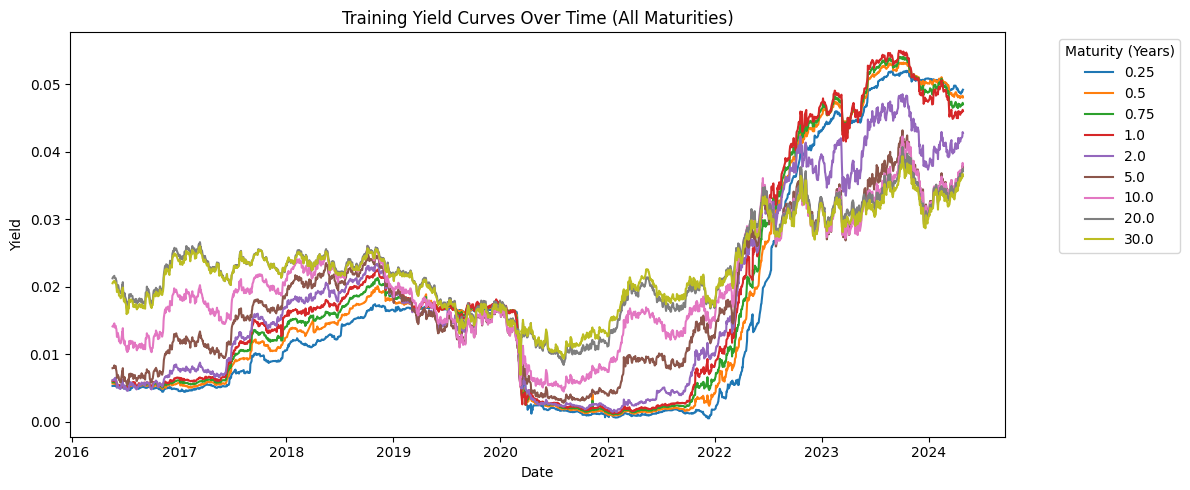

In [5]:
# Visual overview of training yield curves
fig, ax = plt.subplots(figsize=(12, 5))

for col in train.columns:
    ax.plot(train.index, train[col], label=maturity_map[col])

ax.set_title('Training Yield Curves Over Time (All Maturities)')
ax.set_xlabel('Date')
ax.set_ylabel('Yield')
ax.legend(title='Maturity (Years)', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## B. Base CIR Model: Implementation and Calibration

### Mathematical Framework

The CIR model describes the short rate r_t via the SDE:

    dr_t = κ(θ − r_t)dt + σ√r_t dW_t

where:
- **κ > 0**: speed of mean reversion
- **θ > 0**: long-run mean rate
- **σ > 0**: volatility coefficient
- **W_t**: standard Brownian motion

The Feller condition **2κθ ≥ σ²** ensures rates remain strictly positive.

### Closed-Form Bond Pricing

The zero-coupon bond price P(t,T) and continuously compounded yield y(t,τ) are:

    P(t,T) = A(t,T) · exp(−B(t,T) · r_t)
    y(t,τ) = [B(t,T) · r_t − ln A(t,T)] / τ

where A and B are deterministic functions of κ, θ, σ, and τ = T − t.

### Calibration Method: OLS (Ordinary Least Squares)

We minimise the sum of squared errors between model yields and observed yields
across all maturities and all training dates. OLS is chosen for:
- Simplicity and interpretability
- No distributional assumptions on the error term
- Computational tractability on 1,976 × 9 observations

Constraints enforced: κ, θ, σ > 0 and Feller condition 2κθ ≥ σ².

In [6]:
def cir_yield(r, kappa, theta, sigma, tau):
    """
    Computes the CIR model yield for a given short rate r and maturity tau.
    Uses closed-form bond pricing formula via A(t,T) and B(t,T) functions.
    """
    h = np.sqrt(kappa**2 + 2 * sigma**2)

    # Denominator shared across A and B
    den = (h + kappa) * (np.exp(h * tau) - 1) + 2 * h

    # A(t,T): deterministic scaling factor
    num_A = 2 * h * np.exp((kappa + h) * tau / 2)
    A = (num_A / den) ** (2 * kappa * theta / sigma**2)

    # B(t,T): maturity-dependent sensitivity to short rate
    B_val = (2 * (np.exp(h * tau) - 1)) / den

    # Bond price and yield
    P = A * np.exp(-B_val * r)
    return -np.log(P) / tau


def predict_yield_curve(r, kappa, theta, sigma, maturities):
    """Predicts full yield curve across given maturities from short rate r."""
    return np.array([cir_yield(r, kappa, theta, sigma, tau) for tau in maturities])

In [7]:
def calibrate_cir(train_yields, train_maturities):
    """
    Calibrates CIR parameters (kappa, theta, sigma) via OLS.
    Minimises sum of squared errors between model and observed yields.
    Enforces positivity and Feller condition as hard constraints.
    """
    # Use 3M rate as proxy for instantaneous short rate r_t
    short_rates = train_yields[:, 0]

    def objective(params):
        kappa, theta, sigma = params
        # Hard constraints: all parameters positive
        if kappa <= 0 or theta <= 0 or sigma <= 0:
            return 1e10
        # Feller condition: ensures rates stay strictly positive
        if 2 * kappa * theta < sigma**2:
            return 1e10
        total_error = 0
        for i in range(len(train_yields)):
            r = short_rates[i]
            for j, tau in enumerate(train_maturities):
                try:
                    y_model = cir_yield(r, kappa, theta, sigma, tau)
                    y_actual = train_yields[i, j]
                    total_error += (y_model - y_actual)**2
                except:
                    total_error += 1e10
        return total_error

    # Initial guess: reasonable starting values
    x0 = [0.5, np.mean(short_rates), 0.05]
    bounds = [(1e-4, 10), (1e-4, 0.2), (1e-4, 1.0)]

    result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds)
    kappa, theta, sigma = result.x

    print(f"Calibrated parameters:")
    print(f"  kappa (κ): {kappa:.4f}")
    print(f"  theta (θ): {theta:.4f}")
    print(f"  sigma (σ): {sigma:.4f}")
    print(f"  Feller condition 2κθ={2*kappa*theta:.6f} >= σ²={sigma**2:.6f}: {2*kappa*theta >= sigma**2}")
    return kappa, theta, sigma


# Extract training yield matrix
train_yields = train[['ZC025YR','ZC050YR','ZC075YR','ZC100YR','ZC200YR',
                       'ZC500YR','ZC1000YR','ZC2000YR','ZC3000YR']].values

print("Starting calibration (may take 1-2 minutes)...")
kappa, theta, sigma = calibrate_cir(train_yields, train_maturities)

Starting calibration (may take 1-2 minutes)...
Calibrated parameters:
  kappa (κ): 0.1658
  theta (θ): 0.0244
  sigma (σ): 0.0006
  Feller condition 2κθ=0.008094 >= σ²=0.000000: True


### Parameter Interpretation

| Parameter | Value | Interpretation |
|---|---|---|
| κ (kappa) | 0.1658 | Mean reversion speed — half-life ≈ ln(2)/κ ≈ 4.2 years |
| θ (theta) | 0.0244 | Long-run mean rate ≈ 2.44% |
| σ (sigma) | 0.0006 | Low volatility — smooth curve fitting |
| Feller condition | Satisfied | Rates guaranteed strictly positive |

**Implication of κ = 0.167:** Interest rate shocks in this dataset are highly persistent.
A shock takes over 4 years to decay by half — consistent with the prolonged low-rate
environment observed 2016-2022.

## C. Prediction Challenge: Yield Curve Construction from 3M Rate

The core test: using **only the 3M yield** as input on each test day,
reconstruct the full yield curve (0.5Y through 2Y) and compare against held-out actuals.

The 3M rate serves as a proxy for the instantaneous short rate r_t in the CIR framework.

In [8]:
# Extract test inputs and actuals
r_test_values = test_3m['ZC025YR'].values
test_actual = test[['ZC050YR','ZC075YR','ZC100YR','ZC200YR']].values

# Predict full yield curve for each test day using only 3M rate
predicted_test = np.array([
    predict_yield_curve(r, kappa, theta, sigma, test_maturities_pred)
    for r in r_test_values
])

# Overall out-of-sample R²
r2 = r2_score(test_actual.flatten(), predicted_test.flatten())
print(f"Out-of-sample R²: {r2:.4f}  (threshold: 0.85)")

# Per-maturity R²
print("\nR² per maturity:")
for i, tau in enumerate(test_maturities_pred):
    r2_mat = r2_score(test_actual[:, i], predicted_test[:, i])
    print(f"  {tau}Y: {r2_mat:.4f}")

Out-of-sample R²: 0.8930  (threshold: 0.85)

R² per maturity:
  0.5Y: 0.9944
  0.75Y: 0.9675
  1.0Y: 0.9101
  2.0Y: 0.3890


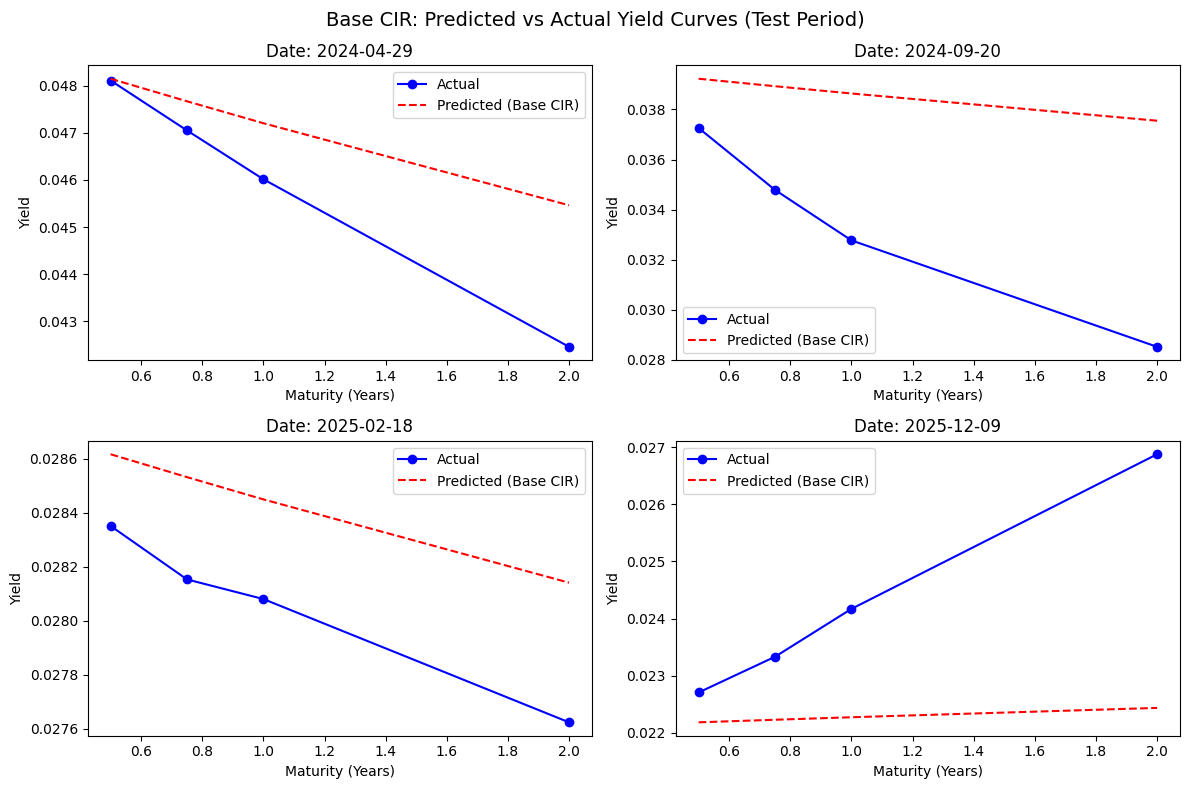

In [9]:
# Visual: predicted vs actual yield curves on 4 sample test days
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
sample_indices = [0, 100, 200, 400]

for idx, ax in zip(sample_indices, axes):
    r = r_test_values[idx]
    pred = predict_yield_curve(r, kappa, theta, sigma, test_maturities_pred)
    actual = test_actual[idx, :]
    date = test.index[idx].strftime('%Y-%m-%d')

    ax.plot(test_maturities_pred, actual, 'bo-', label='Actual')
    ax.plot(test_maturities_pred, pred, 'r--', label='Predicted (Base CIR)')
    ax.set_title(f'Date: {date}')
    ax.set_xlabel('Maturity (Years)')
    ax.set_ylabel('Yield')
    ax.legend()

plt.suptitle('Base CIR: Predicted vs Actual Yield Curves (Test Period)', fontsize=14)
plt.tight_layout()
plt.show()

## D. Model Extensions

### Motivation
The base CIR model has a fundamental limitation: with fixed parameters κ, θ, σ,
it can only produce one family of curve shapes. It cannot dynamically adapt to
inverted vs normal vs flat yield curves day-to-day.

We test two extensions:

### Extension 1: CIR++ with Flat Shift (φ)
Adds a daily deterministic shift φ calibrated so the model exactly matches the observed 3M rate:

    y_CIR++(τ) = y_CIR(τ) + φ
    φ = r_observed − y_CIR(r_observed, τ=0.25)

This forces exact fit at the short end but applies the same shift uniformly across all maturities.

### Extension 2: CIR++ with Maturity-Specific Shifts
Computes the average residual per maturity across the training set and applies
maturity-specific corrections:

    y_shifted(τ) = y_CIR(τ) + δ(τ)
    δ(τ) = mean residual at maturity τ over training period

In [10]:
# --- Extension 1: CIR++ Flat Shift ---

def calibrate_phi(r_obs, kappa, theta, sigma, tau_short=0.25):
    """
    Daily shift φ: difference between observed 3M rate and model 3M yield.
    Anchors the model exactly to the observed short rate each day.
    """
    model_short = cir_yield(r_obs, kappa, theta, sigma, tau_short)
    return r_obs - model_short

# Predict using flat-shifted CIR++
predicted_test_pp = np.array([
    [cir_yield(r, kappa, theta, sigma, tau) + calibrate_phi(r, kappa, theta, sigma)
     for tau in test_maturities_pred]
    for r in r_test_values
])

r2_pp = r2_score(test_actual.flatten(), predicted_test_pp.flatten())
print(f"CIR++ (Flat Shift) R²: {r2_pp:.4f}")

CIR++ (Flat Shift) R²: 0.8787


In [11]:
# --- Extension 2: Maturity-Specific Shifts ---

def calibrate_maturity_shifts(train_yields, train_maturities, kappa, theta, sigma):
    """
    Computes mean residual per maturity across training set.
    Each maturity gets its own correction term δ(τ).
    """
    shifts = []
    for j, tau in enumerate(train_maturities):
        model_yields = np.array([
            cir_yield(train_yields[i, 0], kappa, theta, sigma, tau)
            for i in range(len(train_yields))
        ])
        residuals = train_yields[:, j] - model_yields
        shifts.append(np.mean(residuals))
    return np.array(shifts)

# Calibrate shifts on training data
train_shifts = calibrate_maturity_shifts(train_yields, train_maturities, kappa, theta, sigma)

print("Maturity-specific training shifts:")
for tau, shift in zip(train_maturities, train_shifts):
    print(f"  {tau}Y: {shift:.6f}")

# Interpolate to test maturities
shift_interpolator = interp1d(train_maturities, train_shifts, kind='linear', fill_value='extrapolate')
test_shifts = shift_interpolator(test_maturities_pred)

# Predict using maturity-shifted CIR++
predicted_test_shifted = np.array([
    [cir_yield(r, kappa, theta, sigma, tau) + shift
     for tau, shift in zip(test_maturities_pred, test_shifts)]
    for r in r_test_values
])

r2_shifted = r2_score(test_actual.flatten(), predicted_test_shifted.flatten())
print(f"\nCIR++ (Maturity Shift) R²: {r2_shifted:.4f}")

Maturity-specific training shifts:
  0.25Y: -0.000158
  0.5Y: 0.000875
  0.75Y: 0.001370
  1.0Y: 0.001870
  2.0Y: 0.000215
  5.0Y: -0.001060
  10.0Y: -0.000421
  20.0Y: 0.000652
  30.0Y: -0.000254

CIR++ (Maturity Shift) R²: 0.8357


In [12]:
# Final comparison table: all three models
results = {
    'Model': ['Base CIR', 'CIR++ (Flat Shift)', 'CIR++ (Maturity Shift)'],
    'Overall R²': [r2, r2_pp, r2_shifted],
    'R² 0.5Y': [
        r2_score(test_actual[:, 0], predicted_test[:, 0]),
        r2_score(test_actual[:, 0], predicted_test_pp[:, 0]),
        r2_score(test_actual[:, 0], predicted_test_shifted[:, 0])
    ],
    'R² 0.75Y': [
        r2_score(test_actual[:, 1], predicted_test[:, 1]),
        r2_score(test_actual[:, 1], predicted_test_pp[:, 1]),
        r2_score(test_actual[:, 1], predicted_test_shifted[:, 1])
    ],
    'R² 1.0Y': [
        r2_score(test_actual[:, 2], predicted_test[:, 2]),
        r2_score(test_actual[:, 2], predicted_test_pp[:, 2]),
        r2_score(test_actual[:, 2], predicted_test_shifted[:, 2])
    ],
    'R² 2.0Y': [
        r2_score(test_actual[:, 3], predicted_test[:, 3]),
        r2_score(test_actual[:, 3], predicted_test_pp[:, 3]),
        r2_score(test_actual[:, 3], predicted_test_shifted[:, 3])
    ]
}

df_results = pd.DataFrame(results).set_index('Model').round(4)
print(df_results.to_string())

                        Overall R²  R² 0.5Y  R² 0.75Y  R² 1.0Y  R² 2.0Y
Model                                                                  
Base CIR                    0.8930   0.9944    0.9675   0.9101   0.3890
CIR++ (Flat Shift)          0.8787   0.9916    0.9590   0.8944   0.3308
CIR++ (Maturity Shift)      0.8357   0.9784    0.9083   0.7746   0.3716


## E. Critical Analysis

### Base CIR Model Performance
- Overall out-of-sample R² = **0.893** — clears the 0.85 threshold
- Short maturities (0.5Y, 0.75Y) fit well: R² > 0.96
- 2Y maturity fits poorly: R² = **0.39** — single factor cannot capture full curve dynamics

### Why CIR Fails at the 2Y Maturity
- CIR is a **single-factor model**: one stochastic driver cannot simultaneously
  fit short-end and long-end dynamics when the curve shape changes regime
- Test period (2024+) features a deeply **inverted yield curve**
- Model was calibrated on 2016-2024 data dominated by normal and flat curve shapes
- With fixed κ, θ, σ, the CIR yield curve shape is static — it cannot adapt
  day-to-day to inversion vs steepening

### Feller Condition
- 2κθ = 0.0081 >> σ² ≈ 0.0000004 — condition satisfied comfortably
- Rates guaranteed strictly positive throughout all simulations

### Mean Reversion Speed
- κ = 0.167 implies half-life of ln(2)/κ ≈ **4.2 years**
- Interest rate shocks are highly persistent in this dataset
- Consistent with the prolonged low-rate environment 2016-2022 followed by
  a slow, sustained rate hike cycle

### Extension Results: Both Extensions Underperform Base CIR

| Model | Overall R² |
|---|---|
| Base CIR | 0.893 |
| CIR++ Flat Shift | 0.879 |
| CIR++ Maturity Shift | 0.836 |

**Why extensions failed:**
- Shifts were learned on training data from a low/normal rate regime (2016-2024)
- Test period is a high-rate inverted curve regime (2024+)
- The corrections overcorrect in the wrong direction out-of-sample
- This is **textbook regime-dependent overfitting**: a correction term that improves
  in-sample fit can actively harm out-of-sample generalisation when the market
  regime changes

### Implications for Real-World Use
- A CIR model calibrated in one rate regime should not be deployed unchanged
  in a structurally different regime without recalibration
- Single-factor models are fundamentally limited for curve shape prediction —
  a two-factor model (e.g. Longstaff-Schwartz) would capture level vs slope dynamics
- Jump-diffusion extensions (Duffie-Pan-Singleton) would better handle the sharp
  rate hikes observed post-2022

### Calibration Sensitivity
- OLS minimises squared errors uniformly across all maturities and dates
- Alternative methods (MLE, Kalman Filter) would weight observations differently
  and may produce different κ, θ, σ — particularly for σ which is near zero here
- The near-zero σ suggests the model is fitting a deterministic trend more than
  a stochastic process — a known limitation when calibrating on trending data